In [1]:
# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
 
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ─────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────

DATASET_ROOT  = "C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K"
SPLITS_FILE   = "freshharvest_splits.pt"
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32          # GPU handles 32 fine
NUM_WORKERS   = 0           # Must be 0 on Windows
RANDOM_SEED   = 42
 
# ── Epoch experiments ──────────────────────────────────────────
EPOCH_EXPERIMENTS = [10, 20, 30]
 
# ── Optimizer hyperparameters ──────────────────────────────────
LEARNING_RATE = 0.001
MOMENTUM      = 0.9
 
BINARY_NAMES  = ["Fresh", "Spoiled"]
FRUIT_NAMES   = [
    "Banana", "Lemon", "Lulo", "Mango",
    "Orange", "Strawberry", "Tamarillo", "Tomato"
]
BINARY_LABEL  = {"F": 0, "S": 1}
 
# ── Device setup ───────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"   # only True when GPU is available
print(f"✅ Device : {device}")
if device.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
 
# ── Reproducibility ────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

✅ Device : cuda
   GPU    : NVIDIA GeForce GTX 1650
   VRAM   : 4.0 GB


In [3]:
# ─────────────────────────────────────────────
# 2. TRANSFORMS
# ─────────────────────────────────────────────
 
# ── Same transforms as Week 1 ──────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# ── Train: heavy augmentation ─────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
# ── Val / Test: no augmentation ───────────────────────────────
val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
print("\n✅ Transforms defined.")


✅ Transforms defined.


In [4]:
# ─────────────────────────────────────────────
# 3. DATASET & DATALOADER
# ─────────────────────────────────────────────
 
class FreshHarvestDataset(Dataset):
    """
    Reads FRUIT_16K folder structure.
    F_<Fruit> → Fresh (0) | S_<Fruit> → Spoiled (1)
    """
    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        self.samples   = []
        for folder in sorted(self.root.iterdir()):
            if not folder.is_dir():
                continue
            parts = folder.name.split("_", 1)
            if len(parts) != 2 or parts[0] not in BINARY_LABEL:
                continue
            label = BINARY_LABEL[parts[0]]
            for img_file in sorted(folder.iterdir()):
                if img_file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                    self.samples.append(
                        (str(img_file), label, parts[1], folder.name))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label
 
    @property
    def labels(self):
        return [s[1] for s in self.samples]
 
 
class TransformSubset(Dataset):
    """Applies a specific transform to a subset of FreshHarvestDataset."""
    def __init__(self, base, indices, transform):
        self.base      = base
        self.indices   = indices
        self.transform = transform
 
    def __len__(self):
        return len(self.indices)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.base.samples[self.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label
 
 
# ── Load splits saved in Week 1 ───────────────────────────────
print(f"\n✅ Loading splits from: {SPLITS_FILE}")
splits      = torch.load(SPLITS_FILE, weights_only=False)
train_idx   = splits["train_idx"]
val_idx     = splits["val_idx"]
test_idx    = splits["test_idx"]
 
base_dataset  = FreshHarvestDataset(root=DATASET_ROOT, transform=None)
train_dataset = TransformSubset(base_dataset, train_idx, train_transforms)
val_dataset   = TransformSubset(base_dataset, val_idx,   val_test_transforms)
test_dataset  = TransformSubset(base_dataset, test_idx,  val_test_transforms)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
 
print(f"   Train  : {len(train_dataset):,} images → {len(train_loader)} batches")
print(f"   Val    : {len(val_dataset):,}  images → {len(val_loader)} batches")
print(f"   Test   : {len(test_dataset):,}  images → {len(test_loader)} batches")


✅ Loading splits from: freshharvest_splits.pt
   Train  : 11,200 images → 350 batches
   Val    : 2,400  images → 75 batches
   Test   : 2,400  images → 75 batches


In [5]:
# ─────────────────────────────────────────────
# 4. CNN ARCHITECTURE
# ─────────────────────────────────────────────
#
#  Input  :  224 × 224 × 3
#  Block 1:  Conv(3→32)   + ReLU + MaxPool  →  112×112×32
#  Block 2:  Conv(32→64)  + ReLU + MaxPool  →   56×56×64
#  Block 3:  Conv(64→128) + ReLU + MaxPool  →   28×28×128
#  Block 4:  Conv(128→256)+ ReLU + MaxPool  →   14×14×256
#  Block 5:  Conv(256→512)+ ReLU + MaxPool  →    7×7×512
#  FC     :  Flatten → 25088 → 512 → ReLU → 2
# ─────────────────────────────────────────────
 
class FreshHarvestCNN(nn.Module):
    """
    Custom 5-block CNN for binary fresh/spoiled classification.
    No transfer learning. No regularization (as per task instructions).
    """
    def __init__(self, num_classes=2):
        super().__init__()
 
        self.features = nn.Sequential(
            # Block 1 – 224×224 → 112×112
            nn.Conv2d(3,   32,  kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            # Block 2 – 112×112 → 56×56
            nn.Conv2d(32,  64,  kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            # Block 3 – 56×56 → 28×28
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            # Block 4 – 28×28 → 14×14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            # Block 5 – 14×14 → 7×7
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
 
        # 224 / 2^5 = 7  →  7×7×512 = 25088
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )
 
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
 
 
# ── Sanity check ───────────────────────────────────────────────
_dummy       = torch.zeros(1, 3, 224, 224)
_out         = FreshHarvestCNN()(_dummy)
total_params = sum(p.numel() for p in FreshHarvestCNN().parameters())
assert _out.shape == (1, 2)
print(f"\n✅ CNN Architecture verified.")
print(f"   Total parameters : {total_params:,}")


✅ CNN Architecture verified.
   Total parameters : 14,415,170


In [6]:
# ─────────────────────────────────────────────
# 5. TRAIN & EVAL HELPERS
# ─────────────────────────────────────────────
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total * 100
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total * 100, all_preds, all_labels

In [7]:
# ─────────────────────────────────────────────
# 6. EPOCH EXPERIMENTS
# ─────────────────────────────────────────────
 
experiment_results = {}
 
for NUM_EPOCHS in EPOCH_EXPERIMENTS:
 
    print(f"\n{'='*60}")
    print(f"  🚀 EXPERIMENT : {NUM_EPOCHS} Epochs")
    print(f"{'='*60}")
 
    model     = FreshHarvestCNN(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),
                          lr=LEARNING_RATE, momentum=MOMENTUM)
 
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
    }
    best_val_acc   = 0.0
    best_model_wts = None
 
    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc        = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
 
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
 
        if vl_acc > best_val_acc:
            best_val_acc   = vl_acc
            best_model_wts = {k: v.clone()
                              for k, v in model.state_dict().items()}
 
        tag = " ⭐ best" if vl_acc == best_val_acc else ""
        print(f"  Epoch [{epoch:>3}/{NUM_EPOCHS}] "
              f"│ Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}% "
              f"│ Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%{tag}")
 
    # ── Evaluate test set with best weights ────────────────────
    model.load_state_dict(best_model_wts)
    ts_loss, ts_acc, ts_preds, ts_labels = evaluate(
        model, test_loader, criterion, device)
 
    print(f"\n  ✅ Best Val Acc  : {best_val_acc:.2f}%")
    print(f"  🧪 Test Accuracy : {ts_acc:.2f}%")
 
    experiment_results[NUM_EPOCHS] = {
        "history"      : history,
        "best_val_acc" : best_val_acc,
        "test_acc"     : ts_acc,
        "test_loss"    : ts_loss,
        "test_preds"   : ts_preds,
        "test_labels"  : ts_labels,
        "model_weights": best_model_wts,
    }
 
    # ── Save checkpoint ────────────────────────────────────────
    ckpt_name = f"freshharvest_cnn_{NUM_EPOCHS}ep.pt"
    torch.save({
        "epoch"       : NUM_EPOCHS,
        "model_state" : best_model_wts,
        "val_acc"     : best_val_acc,
        "test_acc"    : ts_acc,
    }, ckpt_name)
    print(f"  💾 Checkpoint saved → {ckpt_name}")


  🚀 EXPERIMENT : 10 Epochs
  Epoch [  1/10] │ Train Loss: 0.6926  Acc: 50.12% │ Val Loss: 0.6914  Acc: 50.00% ⭐ best
  Epoch [  2/10] │ Train Loss: 0.6885  Acc: 55.13% │ Val Loss: 0.6830  Acc: 57.71% ⭐ best
  Epoch [  3/10] │ Train Loss: 0.6752  Acc: 58.11% │ Val Loss: 0.6810  Acc: 52.88%
  Epoch [  4/10] │ Train Loss: 0.6629  Acc: 60.17% │ Val Loss: 0.6558  Acc: 59.75% ⭐ best
  Epoch [  5/10] │ Train Loss: 0.6519  Acc: 62.21% │ Val Loss: 0.6520  Acc: 58.54%
  Epoch [  6/10] │ Train Loss: 0.6314  Acc: 64.80% │ Val Loss: 0.7068  Acc: 52.29%
  Epoch [  7/10] │ Train Loss: 0.5976  Acc: 68.45% │ Val Loss: 0.7143  Acc: 55.83%
  Epoch [  8/10] │ Train Loss: 0.5704  Acc: 70.38% │ Val Loss: 0.6189  Acc: 63.92% ⭐ best
  Epoch [  9/10] │ Train Loss: 0.5481  Acc: 72.29% │ Val Loss: 0.5218  Acc: 73.29% ⭐ best
  Epoch [ 10/10] │ Train Loss: 0.5245  Acc: 73.62% │ Val Loss: 0.5570  Acc: 69.08%

  ✅ Best Val Acc  : 73.29%
  🧪 Test Accuracy : 73.71%
  💾 Checkpoint saved → freshharvest_cnn_10ep.pt

  🚀


🏆 Best experiment : 30 epochs  (Test Acc: 90.67%)


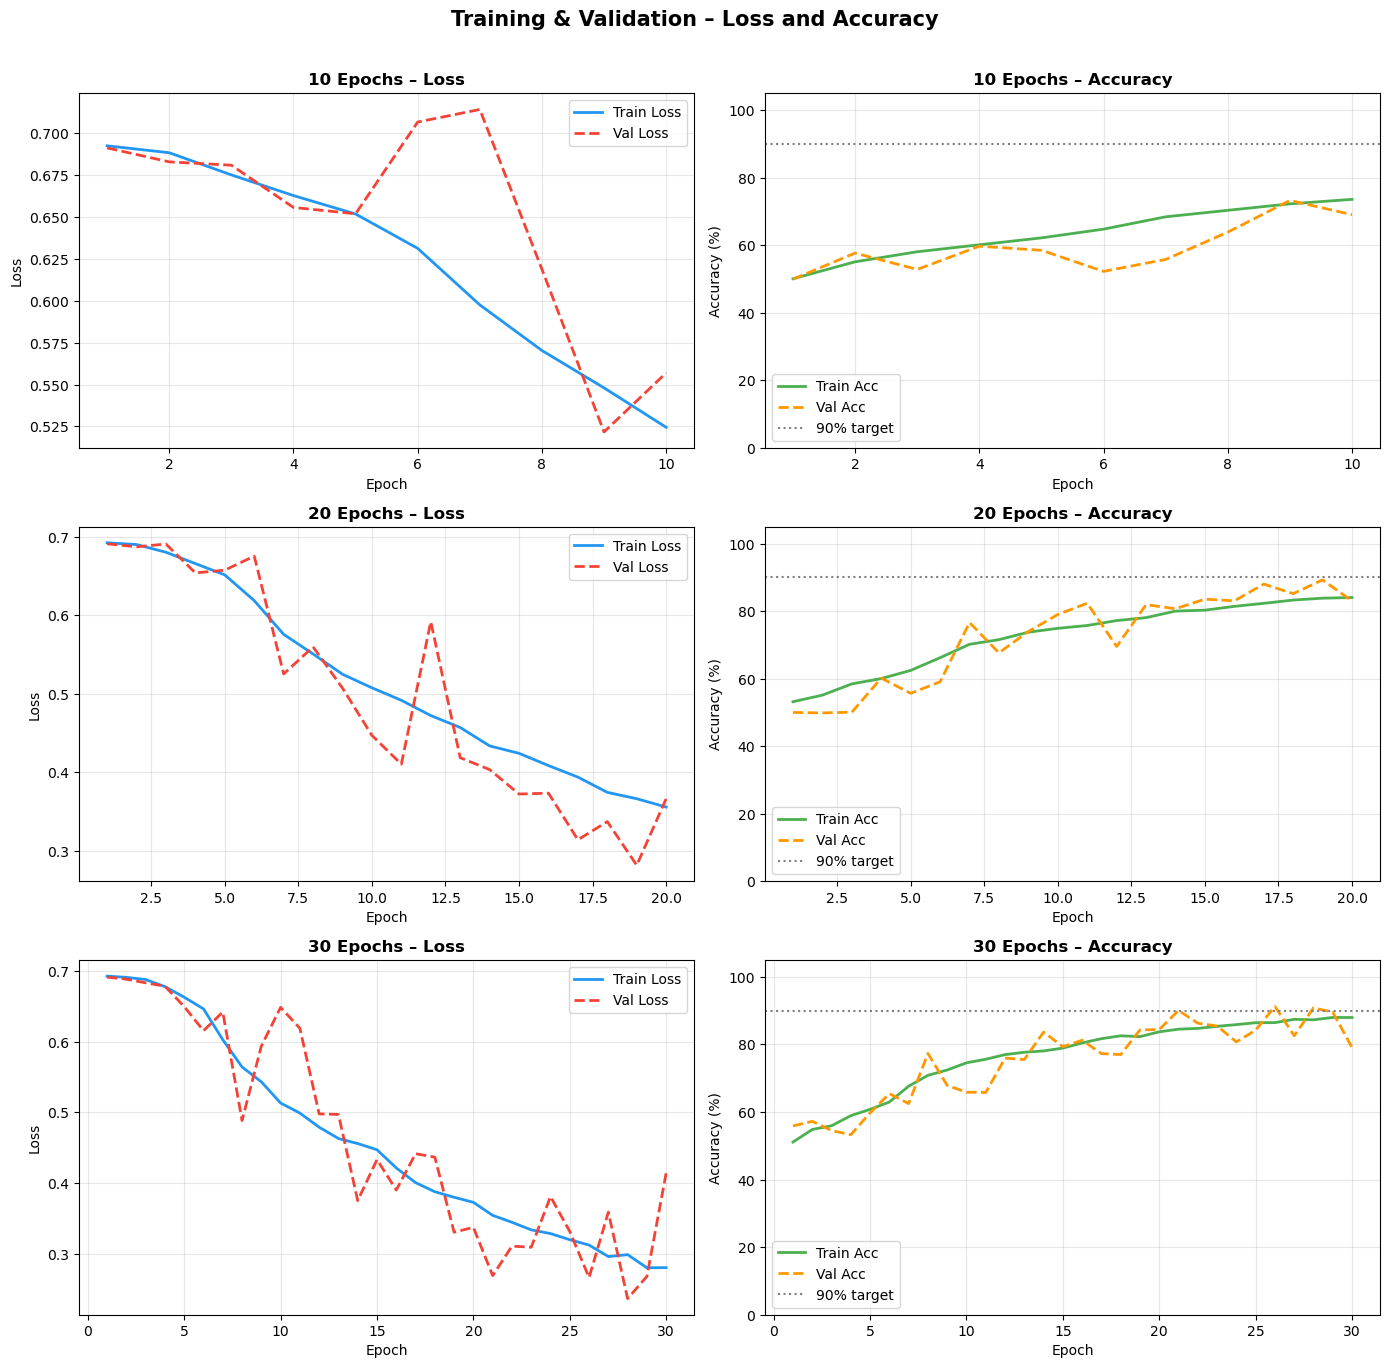

📊 Plot 6 saved → plot6_training_curves.png


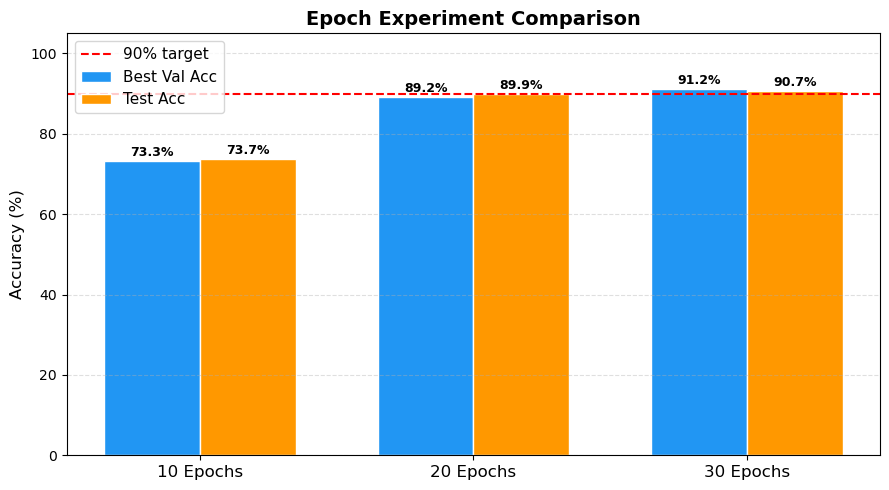

📊 Plot 7 saved → plot7_epoch_comparison.png


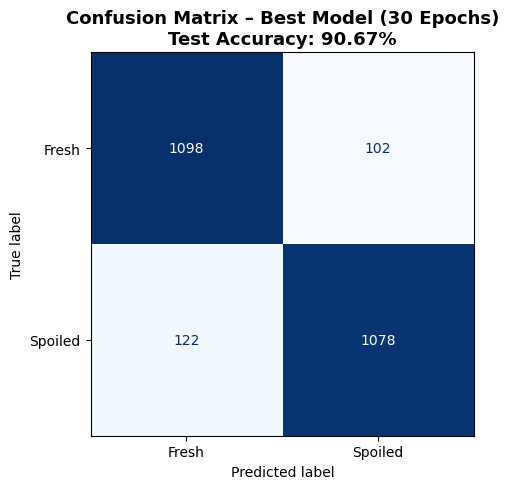

📊 Plot 8 saved → plot8_confusion_matrix.png


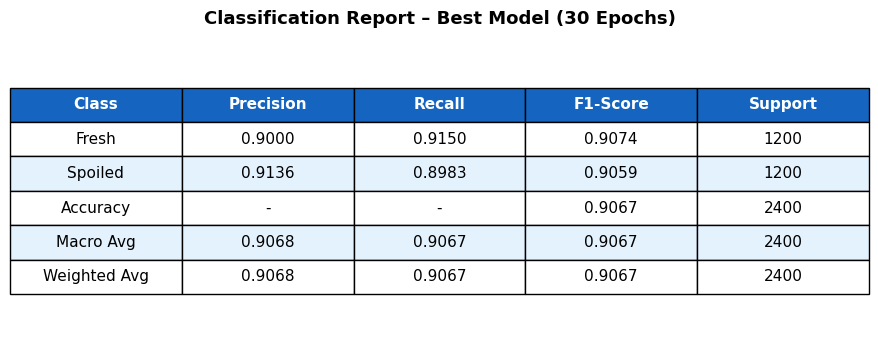

📊 Plot 9 saved → plot9_classification_report.png


In [8]:
# ─────────────────────────────────────────────
# 7. VISUALISATIONS
# ─────────────────────────────────────────────
 
best_exp = max(experiment_results,
               key=lambda e: experiment_results[e]["test_acc"])
best_res = experiment_results[best_exp]
 
print(f"\n🏆 Best experiment : {best_exp} epochs  "
      f"(Test Acc: {best_res['test_acc']:.2f}%)")
 
 
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)
 
 
# ── Plot 1: Training curves for all experiments ───────────────
fig, axes = plt.subplots(len(EPOCH_EXPERIMENTS), 2,
                          figsize=(14, 4.5 * len(EPOCH_EXPERIMENTS)))
fig.suptitle("Training & Validation – Loss and Accuracy",
             fontsize=15, fontweight="bold", y=1.01)
 
for row, ep in enumerate(EPOCH_EXPERIMENTS):
    h   = experiment_results[ep]["history"]
    eps = range(1, ep + 1)
    ax_loss = axes[row][0]
    ax_acc  = axes[row][1]
 
    ax_loss.plot(eps, h["train_loss"], label="Train Loss",
                 color="#2196F3", linewidth=2)
    ax_loss.plot(eps, h["val_loss"],   label="Val Loss",
                 color="#F44336", linewidth=2, linestyle="--")
    ax_loss.set_title(f"{ep} Epochs – Loss", fontsize=12, fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)
 
    ax_acc.plot(eps, h["train_acc"], label="Train Acc",
                color="#4CAF50", linewidth=2)
    ax_acc.plot(eps, h["val_acc"],   label="Val Acc",
                color="#FF9800", linewidth=2, linestyle="--")
    ax_acc.axhline(90, color="grey", linestyle=":", linewidth=1.5,
                   label="90% target")
    ax_acc.set_title(f"{ep} Epochs – Accuracy", fontsize=12, fontweight="bold")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.legend(); ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0, 105)
 
plt.tight_layout()
plt.savefig("plot6_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 6 saved → plot6_training_curves.png")
 
 
# ── Plot 2: Epoch comparison bar chart ────────────────────────
exp_labels = [f"{e} Epochs" for e in EPOCH_EXPERIMENTS]
val_accs   = [experiment_results[e]["best_val_acc"] for e in EPOCH_EXPERIMENTS]
test_accs  = [experiment_results[e]["test_acc"]     for e in EPOCH_EXPERIMENTS]
x = np.arange(len(EPOCH_EXPERIMENTS))
w = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, val_accs,  w, label="Best Val Acc",
            color="#2196F3", edgecolor="white")
b2 = ax.bar(x + w/2, test_accs, w, label="Test Acc",
            color="#FF9800",  edgecolor="white")
ax.axhline(90, color="red", linestyle="--", linewidth=1.5, label="90% target")
ax.set_xticks(x); ax.set_xticklabels(exp_labels, fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.set_title("Epoch Experiment Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar, acc in zip(list(b1) + list(b2), val_accs + test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("plot7_epoch_comparison.png", dpi=150)
plt.show()
print("📊 Plot 7 saved → plot7_epoch_comparison.png")
 
 
# ── Plot 3: Confusion Matrix ──────────────────────────────────
cm   = confusion_matrix(best_res["test_labels"], best_res["test_preds"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=BINARY_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(
    f"Confusion Matrix – Best Model ({best_exp} Epochs)\n"
    f"Test Accuracy: {best_res['test_acc']:.2f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("plot8_confusion_matrix.png", dpi=150)
plt.show()
print("📊 Plot 8 saved → plot8_confusion_matrix.png")
 
 
# ── Plot 4: Classification Report ─────────────────────────────
report = classification_report(
    best_res["test_labels"], best_res["test_preds"],
    target_names=BINARY_NAMES, output_dict=True
)
rows = []
for cls in BINARY_NAMES + ["accuracy", "macro avg", "weighted avg"]:
    if cls == "accuracy":
        rows.append(["Accuracy", "-", "-",
                     f"{report[cls]:.4f}",
                     int(report["macro avg"]["support"])])
    else:
        rows.append([
            cls.title(),
            f"{report[cls]['precision']:.4f}",
            f"{report[cls]['recall']:.4f}",
            f"{report[cls]['f1-score']:.4f}",
            int(report[cls]["support"]),
        ])
 
col_labels = ["Class", "Precision", "Recall", "F1-Score", "Support"]
fig, ax    = plt.subplots(figsize=(9, 3.5))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=col_labels,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1565C0")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#E3F2FD")
ax.set_title(
    f"Classification Report – Best Model ({best_exp} Epochs)",
    fontsize=13, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig("plot9_classification_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 9 saved → plot9_classification_report.png")

In [9]:
# ─────────────────────────────────────────────
# 8. FINAL SUMMARY
# ─────────────────────────────────────────────
 
print("\n" + "="*60)
print("      FRESHHARVEST – WEEK 1 TASK 2 SUMMARY")
print("="*60)
print(f"  Architecture  : Custom CNN (5 Conv Blocks + 2 FC layers)")
print(f"  Parameters    : {total_params:,}")
print(f"  Optimizer     : SGD  (lr={LEARNING_RATE}, momentum={MOMENTUM})")
print(f"  Loss Function : CrossEntropyLoss")
print(f"  Device        : {device}")
print("-"*60)
print(f"  {'Epochs':>8}  │  {'Best Val Acc':>13}  │  {'Test Acc':>10}")
print(f"  {'-'*8}  │  {'-'*13}  │  {'-'*10}")
for ep in EPOCH_EXPERIMENTS:
    r      = experiment_results[ep]
    marker = "  🏆" if ep == best_exp else ""
    print(f"  {ep:>8}  │  {r['best_val_acc']:>12.2f}%  │  "
          f"{r['test_acc']:>9.2f}%{marker}")
print("-"*60)
target = ("✅ TARGET MET!" if best_res["test_acc"] >= 90
          else "⚠️  Below 90% – try more epochs or reduce lr")
print(f"\n  Best Model    : {best_exp} epochs")
print(f"  Val Accuracy  : {best_res['best_val_acc']:.2f}%")
print(f"  Test Accuracy : {best_res['test_acc']:.2f}%   {target}")
print("="*60)
print("\n✅ Task 2 complete – ready for Week 2!\n")


      FRESHHARVEST – WEEK 1 TASK 2 SUMMARY
  Architecture  : Custom CNN (5 Conv Blocks + 2 FC layers)
  Parameters    : 14,415,170
  Optimizer     : SGD  (lr=0.001, momentum=0.9)
  Loss Function : CrossEntropyLoss
  Device        : cuda
------------------------------------------------------------
    Epochs  │   Best Val Acc  │    Test Acc
  --------  │  -------------  │  ----------
        10  │         73.29%  │      73.71%
        20  │         89.25%  │      89.88%
        30  │         91.25%  │      90.67%  🏆
------------------------------------------------------------

  Best Model    : 30 epochs
  Val Accuracy  : 91.25%
  Test Accuracy : 90.67%   ✅ TARGET MET!

✅ Task 2 complete – ready for Week 2!

